# Introducción al aprendizaje automatizado (O2026)
## Tutorial 6 - Parte 2: Comparación & Curvas ROC 

**Objetivo:** Comparar con los modelos de la parte 1 (Logit & Vecinos Ceranos, KNN). También, haremos el análisis de performance con la curva ROC para comparar entre métodos en la muestra de testeo.

Veremos:
- Clasificación
- Repaso de Medidas de precisión
- Curva de ROC
- Comparación de modelos: logit & KNN



In [39]:
import os  
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
from ISLP import load_data

from sklearn import datasets
# librerias para clasificar
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# librerias para hacer enfoque de validación
from sklearn.model_selection import train_test_split

# librerias de métricas de performance
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, recall_score 
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

## Comparación de modelos usando datos del mercado de acciones 

En este ejemplo, vamos a usar datos del [Stock Market S&P](https://islp.readthedocs.io/en/latest/datasets/Weekly.html) libro ISLP. 
Esta base contiene los retornos porcentuales del S&P 500 stock index por 1250 días, desde inicios de 2001 hasta el final de 2005. Para cada fecha, tenemos:
- Lag1, Lag2,..., Lag5: retornos porcentuales de cada uno de los días anteriores.
- Volume: volumen de acciones negociadas (número de acciones diarias negociadas en miles de millones de dólares)
- Today: retorno porcentual de hoy
- Direction: variable binaria que toma valores "Down" y "Up" indicando si el mercado tuvo un retorno positivo o negativo.


In [40]:
# Cargamos los datos de Smarket.
smarket = load_data('Smarket')
smarket

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.19130,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.29650,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.41120,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.27600,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.20570,0.213,Up
...,...,...,...,...,...,...,...,...,...
1245,2005,0.422,0.252,-0.024,-0.584,-0.285,1.88850,0.043,Up
1246,2005,0.043,0.422,0.252,-0.024,-0.584,1.28581,-0.955,Down
1247,2005,-0.955,0.043,0.422,0.252,-0.024,1.54047,0.130,Up
1248,2005,0.130,-0.955,0.043,0.422,0.252,1.42236,-0.298,Down


Veamos las correlaciones.

In [41]:
smarket.corr(numeric_only=True).round(2) #con la opcion numeric_only=True hacemo que no tenga en cuenta Direction (string)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.00,0.03,0.03,0.03,0.04,0.03,0.54,0.03
Lag1,0.03,1.00,-0.03,-0.01,-0.00,-0.01,0.04,-0.03
Lag2,0.03,-0.03,1.00,-0.03,-0.01,-0.00,-0.04,-0.01
Lag3,0.03,-0.01,-0.03,1.00,-0.02,-0.02,-0.04,-0.00
Lag4,0.04,-0.00,-0.01,-0.02,1.00,-0.03,-0.05,-0.01
Lag5,0.03,-0.01,-0.00,-0.02,-0.03,1.00,-0.02,-0.03
Volume,0.54,0.04,-0.04,-0.04,-0.05,-0.02,1.00,0.01
Today,0.03,-0.03,-0.01,-0.00,-0.01,-0.03,0.01,1.00


In [44]:
colormap = plt.cm.viridis
plt.figure(figsize=(8,8))
plt.title('Correlacion de Pearson entre las Xs', y=1.05, size=15)
sns.heatmap(smarket.iloc[:,:-1].corr(),
            linewidths=0.1,
            vmax=1.0, 
            square=True, 
            cmap=colormap, 
            linecolor='white', 
            annot=True)


<Axes: title={'center': 'Correlacion de Pearson entre las Xs'}>

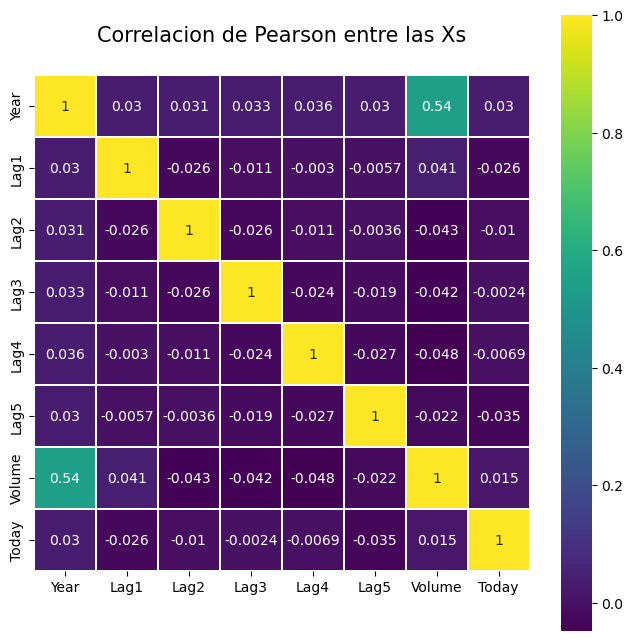

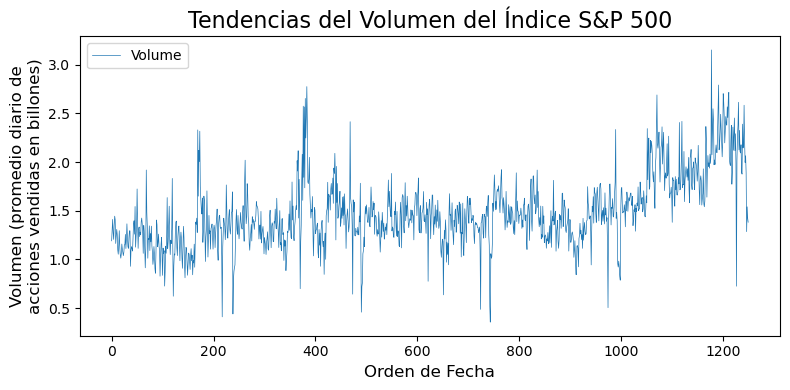

In [45]:
fig, ax = plt.subplots(figsize=(8, 4)) # Un tamaño de gráfico más grande suele verse mejor
smarket.plot(y='Volume', linewidth=.5, ax=ax)
ax.set_title('Tendencias del Volumen del Índice S&P 500', fontsize=16)
ax.set_ylabel('Volumen (promedio diario de\nacciones vendidas en billones)', fontsize=12)
ax.set_xlabel('Orden de Fecha', fontsize=12)
plt.tight_layout() # Ajusta automáticamente los márgenes
plt.show()

In [46]:
print(smarket['Direction'].value_counts().round(2))

Direction
Up      648
Down    602
Name: count, dtype: int64


Vamos a usar el modelo de **regresión logística** para predicir 'Direction' usando los lags 1 a 5 y Volume. 

In [47]:
y = smarket['Direction']
y = y.replace('Up', 1)
y = y.replace('Down', 0)
 
X = smarket[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
X = sm.add_constant(X)

/var/folders/wy/42flyl6d5wl9m3vp2mhsmm6w0000gn/T/ipykernel_15002/3439692450.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  y = y.replace('Up', 1)
/var/folders/wy/42flyl6d5wl9m3vp2mhsmm6w0000gn/T/ipykernel_15002/3439692450.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace('Down', 0)
/var/folders/wy/42flyl6d5wl9m3vp2mhsmm6w0000gn/T/ipykernel_15002/3439692450.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases tha

### Modelo 1: Logit

In [48]:
logit_model = sm.Logit(y.astype(float),X.astype(float))
result = logit_model.fit()
print(result.summary2())

Optimization terminated successfully.
         Current function value: 0.691034
         Iterations 4
                         Results: Logit
Model:              Logit            Method:           MLE      
Dependent Variable: Direction        Pseudo R-squared: 0.002    
Date:               2026-04-21 15:12 AIC:              1741.5841
No. Observations:   1250             BIC:              1777.5004
Df Model:           6                Log-Likelihood:   -863.79  
Df Residuals:       1243             LL-Null:          -865.59  
Converged:          1.0000           LLR p-value:      0.73187  
No. Iterations:     4.0000           Scale:            1.0000   
------------------------------------------------------------------
           Coef.    Std.Err.      z      P>|z|     [0.025   0.975]
------------------------------------------------------------------
const     -0.1260     0.2407   -0.5234   0.6007   -0.5978   0.3458
Lag1      -0.0731     0.0502   -1.4566   0.1452   -0.1714   0.0253
Lag

El signo negativo del coeficiente Lag1 indicaría que si el mercado ayer tuvo un retorno <font color='gree'>positivo</font> es menos probable que hoy lo tenga. Sin embargo, los pvalores son altos, por los que no hay evidencia de una asociación fuerte entre las variables y el output 

In [49]:
y_new = result.predict(X) 
print(y_new)
# Usamos todos los datos para estimar el modelo. Probabilidad del que índice S&P suba, para cada uno de los días

# Clasificador de Bayes
y_new = np.where(y_new>0.5, 1, y_new)
y_new = np.where(y_new<=0.5, 0, y_new)
print(y_new)

0       0.507084
1       0.481468
2       0.481139
3       0.515222
4       0.510781
          ...   
1245    0.519892
1246    0.505926
1247    0.539268
1248    0.526118
1249    0.517917
Length: 1250, dtype: float64
[1. 0. 0. ... 1. 1. 1.]


### Repaso: Medidas de precisión 

Dependiendo la prioridad del problema seguramente vamos a querer usar diferentes métricas. Scikit learn tiene muchas métricas que pueden explorar en el módulo [metrics](https://scikit-learn.org/stable/modules/model_evaluation.html)

- Sensitivity o Recall o True Positive Rate: TP rate = TP/P
- Specificity o True Negative Rate: 1 - FP rate = TN/N
- False Positive Rate o False Alarm Rate: FP rate = FP/N
- False Negative Rate: FN rate = FN/P
- Precision o Positive Predicted Value: TP/(TP+FP)
- Accuracy: (TP+TN)/(P+N)

Nota: Cuidado con las traducciones! "Accuracy" lo pueden encontrar traducido como "precisión" y eso puede generar confusión con la medida "precision" (o positive predicted value). Mi sugerencia es traducir "accuracy" como "exactitud".


[Matriz de confusión](https://www.unite.ai/what-is-a-confusion-matrix/)
<center>
<img src="https://www.unite.ai/wp-content/uploads/2019/12/Preventive_Medicine-e1576294312614.png" width="1000">

</center>

#### Repaso: Matriz de Confusión
La matriz de confusión de sklearn pone en las filas las Y reales y las columnas las Y predichas. Muestra así los valores:

                               predicción
                         real   tn fp
                                fn tp

In [50]:
conf_mat = confusion_matrix(y, y_new) #Python pone en las filas las Y y en las columnas las Y hat (y predichas)

print('Confusion Matrix:\n', conf_mat) 
print('Accuracy Score:',accuracy_score(y, y_new)) # Cantidad de (vp+vn) sobre total
# Acá, la matriz de confusión tiene en las filas los valores ciertos y en las columnas los valores predichos

Confusion Matrix:
 [[145 457]
 [141 507]]
Accuracy Score: 0.5216


### Visualización: Probabilidad predicha P(Y=1 | Lag1)

Una forma de entender el modelo logit es ver cómo cambia la probabilidad predicha según una variable numérica.
Acá graficamos P(Up | Lag1) — la probabilidad de que el índice suba dado el retorno del día anterior — junto con la curva sigmoide que estima el logit.

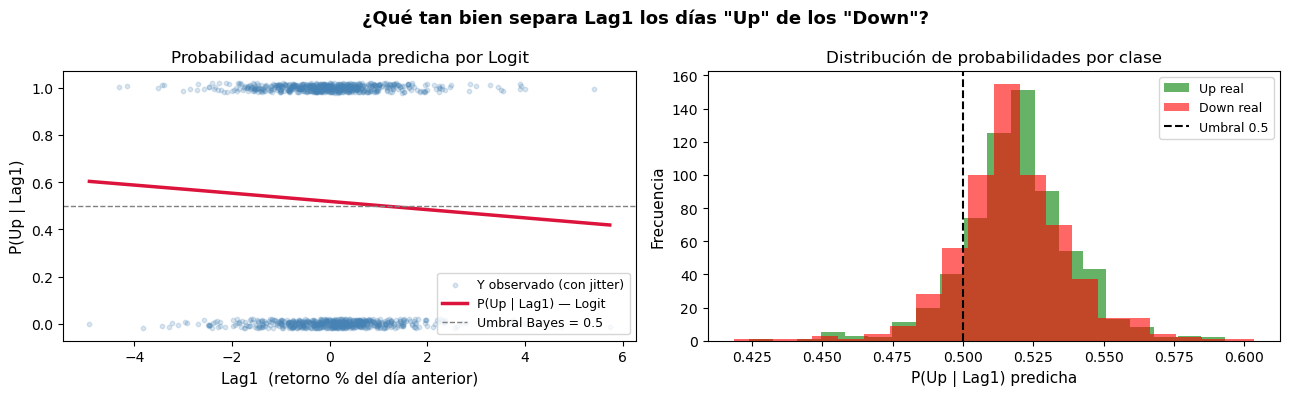

In [51]:
# Logit con solo Lag1 para visualizar la curva sigmoide
X_lag1_full = smarket[['Lag1']].values
y_full = y.values.astype(float)
from sklearn.linear_model import LogisticRegression as LR_viz
log_viz = LR_viz(penalty=None).fit(X_lag1_full, y_full)

lag1_grid = np.linspace(X_lag1_full.min(), X_lag1_full.max(), 300).reshape(-1, 1)
prob_grid  = log_viz.predict_proba(lag1_grid)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Izquierda: scatter + curva sigmoide
rng = np.random.default_rng(0)
jitter = rng.uniform(-0.02, 0.02, size=len(y_full))
axes[0].scatter(X_lag1_full.flatten(), y_full + jitter,
                alpha=0.2, color='steelblue', s=10, label='Y observado (con jitter)')
axes[0].plot(lag1_grid.flatten(), prob_grid, color='crimson', lw=2.5,
             label='P(Up | Lag1) — Logit')
axes[0].axhline(0.5, color='gray', linestyle='--', lw=1, label='Umbral Bayes = 0.5')
axes[0].set_xlabel('Lag1  (retorno % del día anterior)', fontsize=11)
axes[0].set_ylabel('P(Up | Lag1)', fontsize=11)
axes[0].set_title('Probabilidad acumulada predicha por Logit', fontsize=12)
axes[0].legend(fontsize=9)

# Derecha: histograma de probabilidades predichas por clase real
prob_all = log_viz.predict_proba(X_lag1_full)[:, 1]
axes[1].hist(prob_all[y_full == 1], bins=20, alpha=0.6, color='green',  label='Up real')
axes[1].hist(prob_all[y_full == 0], bins=20, alpha=0.6, color='red',    label='Down real')
axes[1].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Umbral 0.5')
axes[1].set_xlabel('P(Up | Lag1) predicha', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].set_title('Distribución de probabilidades por clase', fontsize=12)
axes[1].legend(fontsize=9)

plt.suptitle('¿Qué tan bien separa Lag1 los días "Up" de los "Down"?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Curva ROC                  
ROC: Receiver Operating Characteristics

Veremos como utilizar las funciones:

-  [roc_curve](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html#sklearn.metrics.roc_curve): computa la curva de ROC
- [roc_auc_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html#sklearn.metrics.roc_auc_score): Computa el area bajo la curva de ROC de los scores predichos.
- [RocCurveDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html#sklearn.metrics.RocCurveDisplay): Sirve para visualizar la curva de ROC. Con el mismo fin existe [plot_roc_curve](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.plot_roc_curve.html#sklearn.metrics.plot_roc_curve)

In [52]:
# Para graficar la curva ROC lo mejor es usar la funcion LogisticRegression() 
log_reg = LogisticRegression(penalty=None).fit(X.astype(float), y.astype(float))

# Estimacion de los coeficientes
print(log_reg.coef_)

# Predicciones (probabilidad) 
y_pred_score = log_reg.predict_proba(X)[:,1]   
print(y_pred_score)

[[-0.06308661 -0.07314845 -0.04234797  0.01108602  0.00937296  0.01032962
   0.13553721]]
[0.5070812  0.48142004 0.48108783 ... 0.53928038 0.52612061 0.51791242]


In [53]:
print('Promedio de probabilidad:',y_pred_score.mean().round(2))
print('Min de probabilidad:',y_pred_score.min().round(2))
print('Max de probabilidad:',y_pred_score.max().round(2))

Promedio de probabilidad: 0.52
Min de probabilidad: 0.41
Max de probabilidad: 0.65


In [54]:
# Computamos la tasa de verdaderos positivos (tpr) y falsos positivos (fpr) para construir la curva ROC
fpr, tpr, thresholds = roc_curve(y, y_pred_score) 

#Si es True, siempre imprime los números de punto flotante usando la notación de punto fijo, 
#en cuyo caso los números iguales a cero en la precisión actual se imprimirán como cero.

In [55]:
print('Thresholds:', thresholds)   # Estos son los umbrales c en las slides
print('FPR:', fpr)
print('TPR:', tpr)

Thresholds: [       inf 0.64874927 0.63132124 0.62258382 0.61790123 0.61767609
 0.60993653 0.59754439 0.59744853 0.59377351 0.59345508 0.59298714
 0.58616896 0.58153414 0.58147301 0.57963208 0.57774402 0.57513313
 0.57466944 0.574565   0.573605   0.57340864 0.57296543 0.57104103
 0.56843953 0.56685081 0.56646817 0.56518461 0.56503295 0.56463371
 0.56360742 0.56338511 0.56325282 0.56270402 0.56270097 0.56143792
 0.56066993 0.56019517 0.5597215  0.55967353 0.55938413 0.55881926
 0.55874929 0.55869312 0.55850271 0.55842509 0.5582495  0.55812396
 0.55710466 0.55697543 0.55679904 0.55679657 0.5567494  0.55662244
 0.55644602 0.55611344 0.55589112 0.55551757 0.55529998 0.55452972
 0.55439484 0.55433473 0.55423218 0.55414509 0.55357094 0.55345552
 0.55293169 0.5529291  0.5528986  0.55280726 0.55279772 0.55255597
 0.55234376 0.55180388 0.55173492 0.55098568 0.55083486 0.55040648
 0.55035399 0.55016667 0.55009526 0.5496553  0.54960873 0.54927572
 0.54860939 0.54835148 0.54811259 0.54808775 0.548

In [56]:
#Area under curve (es una medida de precisón)
auc = roc_auc_score(y, y_new) 
print('AUC: %.2f' % auc)



AUC: 0.51


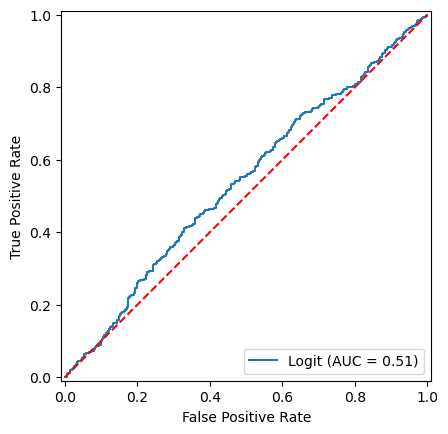

In [59]:
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc, estimator_name='Logit')
display.plot()  
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.show() 

A primera vista, pareciera que la regresión logística funciona apenas mejor que adivinar al azar

In [60]:
# Repetimos pero partiendo la base entre train y test:
train = smarket[smarket.Year < 2005]
test = smarket[smarket.Year >= 2005]
    
ytrain = train['Direction']
ytrain = ytrain.replace('Up', 1)
ytrain = ytrain.replace('Down', 0) 

ytest = test['Direction']
ytest = ytest.replace('Up', 1)
ytest = ytest.replace('Down', 0)

Xtrain = train[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
Xtrain = sm.add_constant(Xtrain) 

Xtest = test[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
Xtest = sm.add_constant(Xtest)

/var/folders/wy/42flyl6d5wl9m3vp2mhsmm6w0000gn/T/ipykernel_15002/402738509.py:6: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  ytrain = ytrain.replace('Up', 1)
/var/folders/wy/42flyl6d5wl9m3vp2mhsmm6w0000gn/T/ipykernel_15002/402738509.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ytrain = ytrain.replace('Down', 0)
/var/folders/wy/42flyl6d5wl9m3vp2mhsmm6w0000gn/T/ipykernel_15002/402738509.py:7: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be u

### Modelo 2: Logit afuera de la muestra
##### Enfoque de validación simple
Hacemos un solo split de las muestras de entrenamiento y testeo.

In [61]:

# Regresión logística
logit_model = sm.Logit(ytrain.astype(float),Xtrain.astype(float))
results = logit_model.fit()
print(results.summary2())

# Probabilidades predichas
y_pred = results.predict(Xtest)
# Predicciones (probabilidad) (p sobrerito)
y_pred_score = log_reg.predict_proba(Xtest)[:,1]   

# Clasificador de Bayes
y_pred=np.where(y_pred>0.5, 1, y_pred)
y_pred=np.where(y_pred<=0.5, 0, y_pred)

# Matriz de confusión
conf_mat = confusion_matrix(ytest, y_pred) 

print('Confusion Matrix:\n', conf_mat) 
print('Accuracy Score:',accuracy_score(ytest, y_pred)) # Cantidad de (vp+vn) sobre total
# Recordar: acá la matriz de confusión tiene en las filas los valores ciertos y en las columnas los valores predichos

Optimization terminated successfully.
         Current function value: 0.691936
         Iterations 4
                         Results: Logit
Model:              Logit            Method:           MLE      
Dependent Variable: Direction        Pseudo R-squared: 0.002    
Date:               2026-04-21 15:21 AIC:              1395.1052
No. Observations:   998              BIC:              1429.4454
Df Model:           6                Log-Likelihood:   -690.55  
Df Residuals:       991              LL-Null:          -691.63  
Converged:          1.0000           LLR p-value:      0.90440  
No. Iterations:     4.0000           Scale:            1.0000   
------------------------------------------------------------------
           Coef.    Std.Err.      z      P>|z|     [0.025   0.975]
------------------------------------------------------------------
const      0.1912     0.3337    0.5730   0.5666   -0.4628   0.8452
Lag1      -0.0542     0.0518   -1.0462   0.2955   -0.1557   0.0473
Lag

### Modelo 3: KNN con enfoque de validación simple

In [67]:
# Vamos a probar con distintos tamaños de k (cantidad de vecinos)
k_range = range(1,10)
scores = {}      # Para guardar la accuracy en un diccionario
scores_list = [] # Para guardar la accuracy en una lista
for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(Xtrain.astype(float), ytrain.astype(float))
        y_pred_knn = knn.predict(Xtest)
        scores[k] = accuracy_score(ytest, y_pred_knn)
        scores_list.append(accuracy_score(ytest, y_pred_knn))

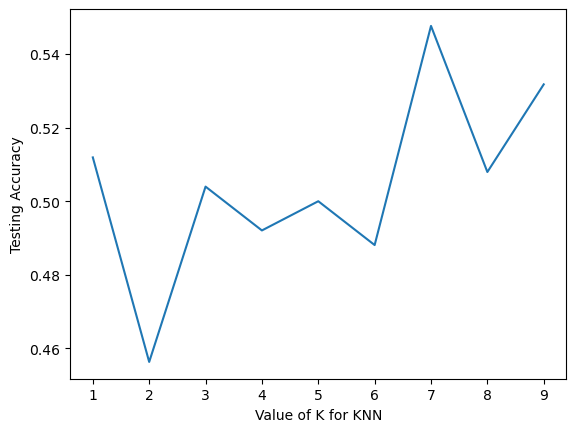

In [68]:
%matplotlib inline
import matplotlib.pyplot as plt

# Graficamos la precisión en base a la cantidad de vecinos
plt.plot(k_range, scores_list)
plt.xlabel('Value of K for KNN')
plt.ylabel('Testing Accuracy')
plt.show()

Numero optimo de vecinos cercanos es $K=7$

In [69]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(Xtrain.astype(float), ytrain.astype(float))

KNeighborsClassifier(n_neighbors=7)

##### Performance de Vecinos cercanos

In [70]:
y_test_pred_knn = knn.predict(Xtest)
accuracy_knn = accuracy_score(ytest, y_test_pred_knn)
print("La exactitud del modelo es: %.3f" %accuracy_knn)  

# Matriz de confusion
print(pd.crosstab(index=ytest, columns=y_test_pred_knn))

La exactitud del modelo es: 0.548
col_0      0.0  1.0
Direction          
0           56   55
1           59   82


### Frontera de clasificación de KNN (K=7)

Visualizamos qué combinaciones de Lag1 y Lag2 llevan al modelo a predecir "Up" vs "Down".
La región de color es la predicción; los puntos son las observaciones reales del test.

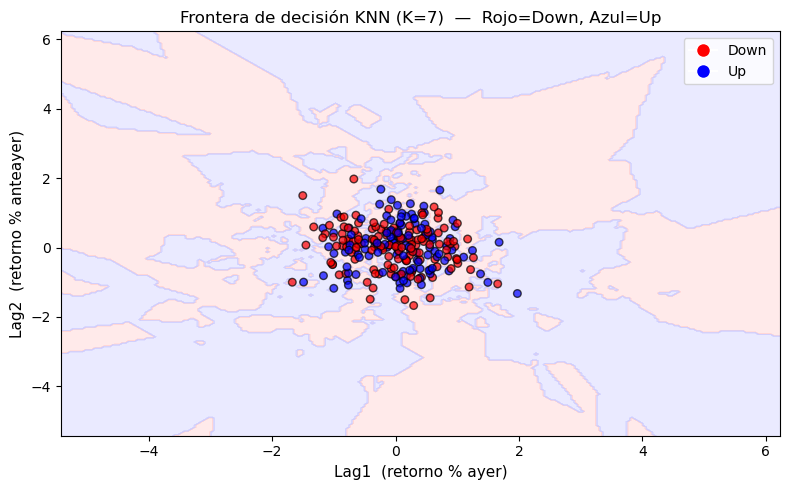

In [71]:
from matplotlib.colors import ListedColormap

# Solo usamos Lag1 y Lag2 para poder graficar en 2D
X_2d_train = Xtrain[['Lag1', 'Lag2']].values
X_2d_test  = Xtest[['Lag1', 'Lag2']].values
y_tr2 = ytrain.values
y_te2 = ytest.values

knn_2d = KNeighborsClassifier(n_neighbors=7)
knn_2d.fit(X_2d_train, y_tr2)

# Meshgrid para dibujar la región
x_min, x_max = X_2d_train[:,0].min()-0.5, X_2d_train[:,0].max()+0.5
y_min, y_max = X_2d_train[:,1].min()-0.5, X_2d_train[:,1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

cmap_bg = ListedColormap(['#FFCCCC', '#CCCCFF'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
ax.scatter(X_2d_test[:,0], X_2d_test[:,1],
           c=y_te2, cmap='bwr', edgecolors='k', s=30, alpha=0.7, zorder=2)
ax.set_xlabel('Lag1  (retorno % ayer)', fontsize=11)
ax.set_ylabel('Lag2  (retorno % anteayer)', fontsize=11)
ax.set_title('Frontera de decisión KNN (K=7)  —  Rojo=Down, Azul=Up', fontsize=12)
handles = [
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='red',  markersize=10, label='Down'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Up'),
]
ax.legend(handles=handles)
plt.tight_layout()
plt.show()

### Test de permutación para KNN

**Pregunta:** ¿El KNN aprende señal real o simplemente memoriza ruido?

**Idea:** Si mezclamos aleatoriamente las etiquetas Y del test muchas veces y el accuracy real es mayor que casi todas las permutaciones, hay evidencia de que el modelo captura una señal real en los datos.

- $H_0$: el modelo no tiene mejor performance que el azar
- $H_1$: el modelo captura señal real
- **p-valor** = proporción de permutaciones con accuracy ≥ accuracy real

Accuracy real del KNN (K=7): 0.5476
p-valor (permutation test): 0.0970
→ No hay evidencia de que KNN capture señal real al 5%


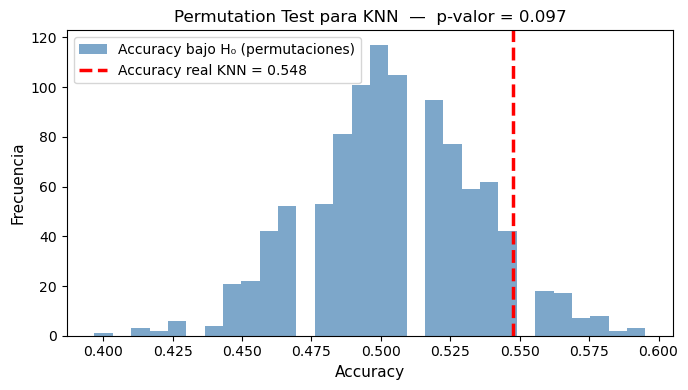

In [72]:
# Permutation Test para KNN
np.random.seed(42)
N_PERM = 1000

acc_real = accuracy_score(ytest, knn.predict(Xtest.astype(float)))
print(f"Accuracy real del KNN (K=7): {acc_real:.4f}")

acc_perm = []
for _ in range(N_PERM):
    y_shuffled = np.random.permutation(ytest.values)
    acc_perm.append(accuracy_score(y_shuffled, knn.predict(Xtest.astype(float))))

acc_perm = np.array(acc_perm)
p_val = (acc_perm >= acc_real).mean()

print(f"p-valor (permutation test): {p_val:.4f}")
print(f"→ {'Hay' if p_val < 0.05 else 'No hay'} evidencia de que KNN capture señal real al 5%")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(acc_perm, bins=30, color='steelblue', alpha=0.7, label='Accuracy bajo H₀ (permutaciones)')
ax.axvline(acc_real, color='red', lw=2.5, linestyle='--',
           label=f'Accuracy real KNN = {acc_real:.3f}')
ax.set_xlabel('Accuracy', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.set_title(f'Permutation Test para KNN  —  p-valor = {p_val:.3f}', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

### Curva ROC para KNN — Comparación con Logit

Completamos la tarea del final del notebook: graficamos la curva ROC del KNN y la comparamos con la del modelo Logit (ambos evaluados **fuera de la muestra**).

In [ ]:
# ROC y AUC para KNN (test set)
y_prob_knn = knn.predict_proba(Xtest.astype(float))[:, 1]

# Re-entrenamos logit con train para comparación justa fuera de muestra
log_oos = LogisticRegression(penalty=None).fit(Xtrain.astype(float), ytrain.astype(float))
y_prob_logit_oos = log_oos.predict_proba(Xtest.astype(float))[:, 1]

fpr_knn,   tpr_knn,   _ = roc_curve(ytest, y_prob_knn)
fpr_logit, tpr_logit, _ = roc_curve(ytest, y_prob_logit_oos)

auc_knn   = roc_auc_score(ytest, y_prob_knn)
auc_logit = roc_auc_score(ytest, y_prob_logit_oos)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_knn,   tpr_knn,   color='darkorange', lw=2, label=f'KNN K=7  (AUC = {auc_knn:.3f})')
ax.plot(fpr_logit, tpr_logit, color='steelblue',  lw=2, label=f'Logit    (AUC = {auc_logit:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio (AUC = 0.500)')
ax.set_xlabel('Tasa de Falsos Positivos  (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos  (TPR)', fontsize=11)
ax.set_title('Curva ROC — Comparación Logit vs KNN  (test set)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

# --- Tabla de performance ---
y_hat_logit = log_oos.predict(Xtest.astype(float))
y_hat_knn   = knn.predict(Xtest.astype(float))

print("\n=== Tabla comparativa: test set ===")
print(f"{'Métrica':<12} {'Logit':>10} {'KNN (K=7)':>12}")
print("-" * 37)
print(f"{'Accuracy':<12} {accuracy_score(ytest, y_hat_logit):>10.4f} {accuracy_score(ytest, y_hat_knn):>12.4f}")
print(f"{'Recall':<12} {recall_score(ytest, y_hat_logit):>10.4f} {recall_score(ytest, y_hat_knn):>12.4f}")
print(f"{'AUC-ROC':<12} {auc_logit:>10.4f} {auc_knn:>12.4f}")